# 🧰 Instalación de Python, Anaconda y Jupyter Notebook en Windows

Esta guía te ayudará a instalar todo lo necesario para trabajar con Python y notebooks.

---

## 🔹 Opción recomendada: Instalar Anaconda (incluye todo)

👉 **Anaconda ya incluye Python, Jupyter Notebook y muchas librerías útiles**

### 1. Descargar Anaconda

Ir al sitio oficial:  
👉 https://www.anaconda.com/download

- Selecciona **Windows**
- Descarga la versión de **64-bit (Python 3.x)**

---

### 2. Instalar Anaconda

- Ejecuta el archivo descargado
- Haz clic en **Next**
- Acepta los términos
- Selecciona **Just Me (recommended)**
- ⚠️ Marca la opción:
  - ✔️ *Add Anaconda to my PATH* (opcional pero útil)
- Finaliza la instalación

---

### 3. Abrir Jupyter Notebook

Después de instalar:

- Busca en el menú inicio: **Anaconda Navigator**
- Ábrelo
- Haz clic en **Launch** en Jupyter Notebook

---

## 🔹 Opción alternativa: Instalar Python manualmente

### 1. Descargar Python

👉 https://www.python.org/downloads/

---

### 2. Instalar Python

- Ejecuta el instalador
- ⚠️ IMPORTANTE: marca:

```text
✔️ Add Python to PATH

**The Bisection Method**

*Quarteroni, A., Sacco, R., & Saleri, F. , 2000. Numerical Mathematics*

The bisection method is based on the following property.

**Property 6.1 (theorem of zeros for continuous functions)**  

*Given a continuous function*  $f : [a,b] \to \mathbb{R}$ *such that* $f(a)f(b) < 0$ *then there exists* $\alpha \in (a,b)$ *such that* $f(\alpha) = 0.$

Partimos de un intervalo inicial  

$$
I_0 = [a,b]
$$

donde la función cambia de signo, es decir:

$$
f(a)\,f(b) < 0
$$

Esto garantiza que existe una raíz dentro del intervalo.

---

### 🔁 Idea del método

En cada paso:

1. Calculamos el punto medio:
   
   $$
   x^{(k)} = \frac{a^{(k)} + b^{(k)}}{2}
   $$

2. Evaluamos la función en ese punto y vemos en qué mitad está la raíz:

   - Si  
     $$
     f(x^{(k)})\,f(a^{(k)}) < 0
     $$
     entonces la raíz está entre \(a^{(k)}\) y \(x^{(k)}\), así que:
     
     $$
     a^{(k+1)} = a^{(k)}, \quad b^{(k+1)} = x^{(k)}
     $$

   - Si no, entonces la raíz está entre \(x^{(k)}\) y \(b^{(k)}\), así que:
     
     $$
     a^{(k+1)} = x^{(k)}, \quad b^{(k+1)} = b^{(k)}
     $$

3. Repetimos el proceso con el nuevo intervalo.

---

### 🧠 Intuición

Cada vez:

- Partes el intervalo a la mitad  
- Te quedas con la mitad donde **seguro está la raíz**  
- El intervalo se hace cada vez más pequeño  

---

### 📉 ¿Qué muestran las figuras?

<img src="Bisección.png" width="800">

- **Gráfico izquierdo:** cómo el intervalo se va reduciendo hacia la raíz \( \alpha \)
- **Gráfico derecho:** el error disminuye rápidamente (escala logarítmica)

---

### ✅ En resumen

El método de bisección consiste en:

> "Ir cortando el intervalo a la mitad y quedarse siempre con la parte donde hay cambio de signo"

Es un método **seguro pero no tan rápido**.

In [17]:
import numpy as np                          # Librería para operaciones numéricas

# Polinomio de Legendre grado 5
def P5(x):                                  # Definimos la función P5
    return (1/8)*(63*x**5 - 70*x**3 + 15*x) # Fórmula del polinomio

def biseccion(a, b, tol, nmax, f):          # Función del método de bisección
    err = tol + 1                           # Inicializamos el error (mayor que la tolerancia)
    nit = 0                                 # Contador de iteraciones
    
    xvect = []                              # Lista para guardar aproximaciones x_k
    fx = []                                 # Lista para guardar f(x_k)
    xdif = []                               # Lista para guardar el error en cada iteración
    
    if f(a)*f(b) >= 0:                      # Verificamos cambio de signo
        raise ValueError("No hay cambio de signo en el intervalo")
    print(f"{'Iter':>5} {'x':>12} {'f(x)':>12} {'Error':>12}")     # Encabezado de la tabla
    print("-"*45)                                                  # Línea separadora
    
    while nit < nmax and err > tol:         # Condición de parada
        nit += 1                            # Aumentamos el contador
        
        c = (a + b) / 2                     # Calculamos el punto medio
        fc = f(c)                           # Evaluamos la función en c
        
        xvect.append(c)                     # Guardamos el punto medio
        fx.append(fc)                       # Guardamos el valor de la función
        
        if f(a)*fc > 0:                     # ¿f(a) y f(c) tienen el mismo signo?
            a = c                           # La raíz está en [c, b]
        else:
            b = c                           # La raíz está en [a, c]
        
        err = abs(b - a)                    # Calculamos el error (tamaño del intervalo)
        xdif.append(err)                    # Guardamos el error     
         
        
        print(f"{nit:5d} {c:12.6f} {fc:12.2e} {err:12.2e}")
        # nit: número de iteración (entero, ancho 5)
        # c: punto medio (12 espacios, 6 decimales)
        # fc: f(c) en notación científica (12 espacios, 2 decimales)
        # err: error en notación científica
    
    return xvect, fx, xdif, nit             # Retornamos resultados

# Ejemplo de uso
xvect, fx, xdif, nit = biseccion(0.6, 1, 10e-10, 100, P5)

print("\nÚltima aproximación:", xvect[-1]) # Mostramos la raíz aproximada

 Iter            x         f(x)        Error
---------------------------------------------
    1     0.800000    -4.00e-01     2.00e-01
    2     0.900000    -4.11e-02     1.00e-01
    3     0.950000     3.73e-01     5.00e-02
    4     0.925000     1.42e-01     2.50e-02
    5     0.912500     4.48e-02     1.25e-02
    6     0.906250     4.82e-04     6.25e-03
    7     0.903125    -2.07e-02     3.13e-03
    8     0.904687    -1.02e-02     1.56e-03
    9     0.905469    -4.87e-03     7.81e-04
   10     0.905859    -2.20e-03     3.91e-04
   11     0.906055    -8.59e-04     1.95e-04
   12     0.906152    -1.89e-04     9.77e-05
   13     0.906201     1.47e-04     4.88e-05
   14     0.906177    -2.12e-05     2.44e-05
   15     0.906189     6.27e-05     1.22e-05
   16     0.906183     2.07e-05     6.10e-06
   17     0.906180    -2.50e-07     3.05e-06
   18     0.906181     1.02e-05     1.53e-06
   19     0.906181     4.99e-06     7.63e-07
   20     0.906180     2.37e-06     3.81e-07
   21    

## 📉 Interpretación del error en el método de bisección

La gráfica muestra la evolución del error \( |b - a| \) en cada iteración del método de bisección aplicada al polinomio de Legendre de grado 5.

### 🔍 Observaciones

- El error **disminuye de forma monótona**, es decir, en cada iteración es menor que en la anterior.
- En escala logarítmica (semilogy), la gráfica es aproximadamente una **línea recta**, lo que indica una **convergencia lineal**.
- Esto significa que el error se reduce aproximadamente a la mitad en cada iteración:

$$
\text{error}_k \approx \frac{b-a}{2^k}
$$

---

### 🧠 Interpretación

El método de bisección es un método:

- ✅ **Seguro**: siempre converge si hay cambio de signo  
- ❌ **Lento**: la convergencia es lineal (no es rápida)

---

### 📌 En este caso (polinomio de Legendre)

- El método está encontrando una raíz de \( P_5(x) \)
- La disminución regular del error confirma que:
  - el intervalo inicial fue bien elegido
  - la función cumple continuidad
  - hay una raíz en el intervalo

---

### 🎯 Conclusión

> La gráfica confirma que el método de bisección converge de manera estable y predecible, reduciendo el error a la mitad en cada iteración hasta alcanzar la tolerancia deseada.

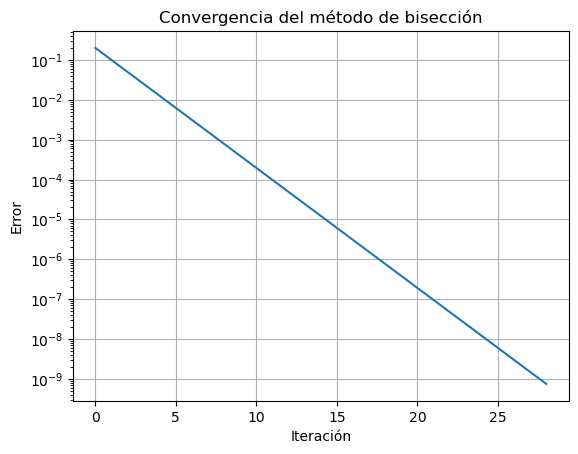

In [18]:
import matplotlib.pyplot as plt

plt.semilogy(xdif)
plt.title("Convergencia del método de bisección")
plt.xlabel("Iteración")
plt.ylabel("Error")
plt.grid()
plt.show()

# 📝 Ejercicios: Método de Bisección

## 🔹 Ejercicio 1: Comprensión básica

Ejecuta el código con el polinomio de Legendre \( P_5(x) \) en distintos intervalos:

- \([0.6, 1]\)
- \([0, 0.5]\)
- \([-1, -0.5]\)

### Preguntas:
- ¿En cuáles intervalos funciona el método?
- ¿Por qué en algunos casos aparece error?
- ¿Qué condición debe cumplirse siempre?

---

## 🔹 Ejercicio 2: Interpretación de la tabla

Observa la salida del programa:

- ¿Qué representa la columna **x**?
- ¿Qué significa **f(x)**?
- ¿Por qué el **error siempre disminuye**?

---

## 🔹 Ejercicio 3: Criterio de parada

Modifica la tolerancia:

- Usa \(10^{-3}\), \(10^{-6}\), \(10^{-10}\)

### Preguntas:
- ¿Cómo cambia el número de iteraciones?
- ¿Qué pasa si la tolerancia es muy pequeña?

---
## 🔹 Ejercicio 4: Cambiar la función

Aplica el método de bisección a la siguiente función:

$$
f(x) = x^3 - x - 2
$$

### 📝 Tarea

Encuentra una raíz en el intervalo:

$$
[1,2]
$$

---

### ❓ Preguntas

- Verifica que se cumple la condición:
  
  $$
  f(1)\,f(2) < 0
  $$

- ¿Cuántas iteraciones necesitas para alcanzar una tolerancia de \(10^{-6}\)?
- ¿Cuál es la aproximación de la raíz obtenida?
